## Fama-French Three Factor Model
Answers what the asset price should be based on market, size, and value factors.

**Factor Interpretations:**
- Market Beta (β): Systematic risk
- SMB (Small Minus Big): Size premium
- HML (High Minus Low): Value premium
- Alpha (α): Excess return

In [1]:
generate_report <- function(results, ticker) {
    cat(sprintf("
Fama-French Three Factor Model Analysis for %s
================================================
Interpretation:
-     alpha: %.4f. %s. %s the market.
- beta_mkt:  %.4f. %s. %s sensitivity to market swings.
- beta_smb:  %.4f. %s. Asset behaves like %s Caps.
- beta_hml:  %.4f. %s. Asset behaves like %s stocks.\n",
        ticker,
        results$alpha,
        ifelse(results$alpha >= 0,"Positive","Negative"),
        ifelse(results$alpha >= 0,"Outperforming","Underperforming"),
        results$beta_mkt,
        ifelse(results$beta_mkt > 1,"Aggressive","Defensive"),
        ifelse(results$beta_mkt > 1,"High","Low"),
        results$beta_smb,
        ifelse(results$beta_smb > 0,"Positive","Negative"),
        ifelse(results$beta_smb > 0,"Small","Large"),
        results$beta_hml,
        ifelse(results$beta_hml > 0,"Positive","Negative"),
        ifelse(results$beta_hml > 0,"Value","Growth")
    ))
}

In [3]:
library(dplyr)
library(ggplot2)

### Load Fama-French 3 Factors

In [4]:
fff <- read.csv("../../../data/F-F_Research_Data_Factors_daily.csv",
               skip=4, header=TRUE, stringsAsFactors=FALSE)
# Remove footer rows (non-numeric index)
fff <- fff[!is.na(suppressWarnings(as.integer(fff[,1]))), ]
fff[,1] <- as.integer(fff[,1])
rownames(fff) <- fff[,1]
fff <- fff[,-1]  # drop date column (now in rownames)
fff[] <- lapply(fff, function(x) as.numeric(x) / 100)
colnames(fff) <- trimws(colnames(fff))

In [5]:
tail(fff)

,Mkt.RF,SMB,HML,RF
,<dbl>,<dbl>,<dbl>,<dbl>
20251120,-0.0158,0.0009,0.0043,0.0002
20251121,0.0103,0.0166,0.0074,0.0002
20251124,0.0161,0.0030,-0.0096,0.0002
20251125,0.0104,0.0165,0.0004,0.0002
20251126,0.0069,-0.0006,-0.0007,0.0002
20251128,0.0054,-0.0042,0.0036,0.0002


In [6]:
start_date <- 20241001L
end_date   <- 20250930L

### TSLA

In [7]:
ticker <- "TSLA"
asset  <- read.csv(sprintf("../../../data/%s.Daily.csv", ticker))
asset$index <- as.integer(gsub("-","", asset$timestamp))
rownames(asset) <- asset$index
asset$returns   <- c(NA, diff(asset$close)/head(asset$close,-1))

merged_data <- merge(fff, asset[,"returns",drop=FALSE],
                     by="row.names", all=FALSE)
rownames(merged_data) <- as.integer(merged_data$Row.names)
merged_data$Row.names <- NULL

In [8]:
tail(merged_data)

,Mkt.RF,SMB,HML,RF,returns
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
20251120,-0.0158,0.0009,0.0043,0.0002,-0.0216837
20251121,0.0103,0.0166,0.0074,0.0002,-0.0104749
20251124,0.0161,0.0030,-0.0096,0.0002,0.0682452
20251125,0.0104,0.0165,0.0004,0.0002,0.0038776
20251126,0.0069,-0.0006,-0.0007,0.0002,0.0171197
20251128,0.0054,-0.0042,0.0036,0.0002,0.0084158


### Fit the Fama-French Model

In [9]:
train <- merged_data[rownames(merged_data) >= start_date &
                       rownames(merged_data) <= end_date, ]
test  <- merged_data[rownames(merged_data) > end_date, ]
train <- na.omit(train)

X_train <- cbind(const=1, train[, c("Mkt.RF","SMB","HML")])
y_train <- train$returns - train$RF

ff_model <- lm(y_train ~ Mkt.RF + SMB + HML, data = train,
               offset = -train$RF)
# Proper way:
ff_model <- lm(I(returns - RF) ~ Mkt.RF + SMB + HML, data = train)
summary(ff_model)


Call:
lm(formula = I(returns - RF) ~ Mkt.RF + SMB + HML, data = train)

Residuals:
     Min       1Q   Median       3Q      Max 
-0.13389 -0.01992 -0.00219  0.01702  0.20981 

Coefficients:
            Estimate Std. Error t value            Pr(>|t|)    
(Intercept)  0.00168    0.00218    0.77                0.44    
Mkt.RF       2.26759    0.20188   11.23 <0.0000000000000002 ***
SMB          0.30861    0.34598    0.89                0.37    
HML         -0.16057    0.30093   -0.53                0.59    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 0.0343 on 246 degrees of freedom
Multiple R-squared:  0.418,	Adjusted R-squared:  0.411 
F-statistic: 58.9 on 3 and 246 DF,  p-value: <0.0000000000000002


In [10]:
params <- list(
    alpha    = coef(ff_model)["(Intercept)"],
    beta_mkt = coef(ff_model)["Mkt.RF"],
    beta_smb = coef(ff_model)["SMB"],
    beta_hml = coef(ff_model)["HML"]
)
generate_report(params, ticker)


Fama-French Three Factor Model Analysis for TSLA
Interpretation:
-     alpha: 0.0017. Positive. Outperforming the market.
- beta_mkt:  2.2676. Aggressive. High sensitivity to market swings.
- beta_smb:  0.3086. Positive. Asset behaves like Small Caps.
- beta_hml:  -0.1606. Negative. Asset behaves like Growth stocks.


### Structure data for plotting

In [11]:
oot_returns <- predict(ff_model, newdata=test)

rfr <- merged_data$RF
in_sample_with_rf  <- fitted(ff_model) + train$RF
oot_with_rf        <- oot_returns + test$RF

asset_sub <- asset[asset$index >= start_date, c("index","close","returns")]
model_out <- data.frame(
    index      = c(as.integer(rownames(train)), as.integer(rownames(test))),
    model_ret  = c(in_sample_with_rf, oot_with_rf),
    is_oos     = c(rep(FALSE,nrow(train)), rep(TRUE, nrow(test)))
)
plot_df <- merge(asset_sub, model_out, by="index")
plot_df$date        <- as.Date(as.character(plot_df$index), format="%Y%m%d")
plot_df$model_price <- dplyr::lag(plot_df$close) * (1 + plot_df$model_ret)

### In-sample and out-of-sample (shaded) comparison

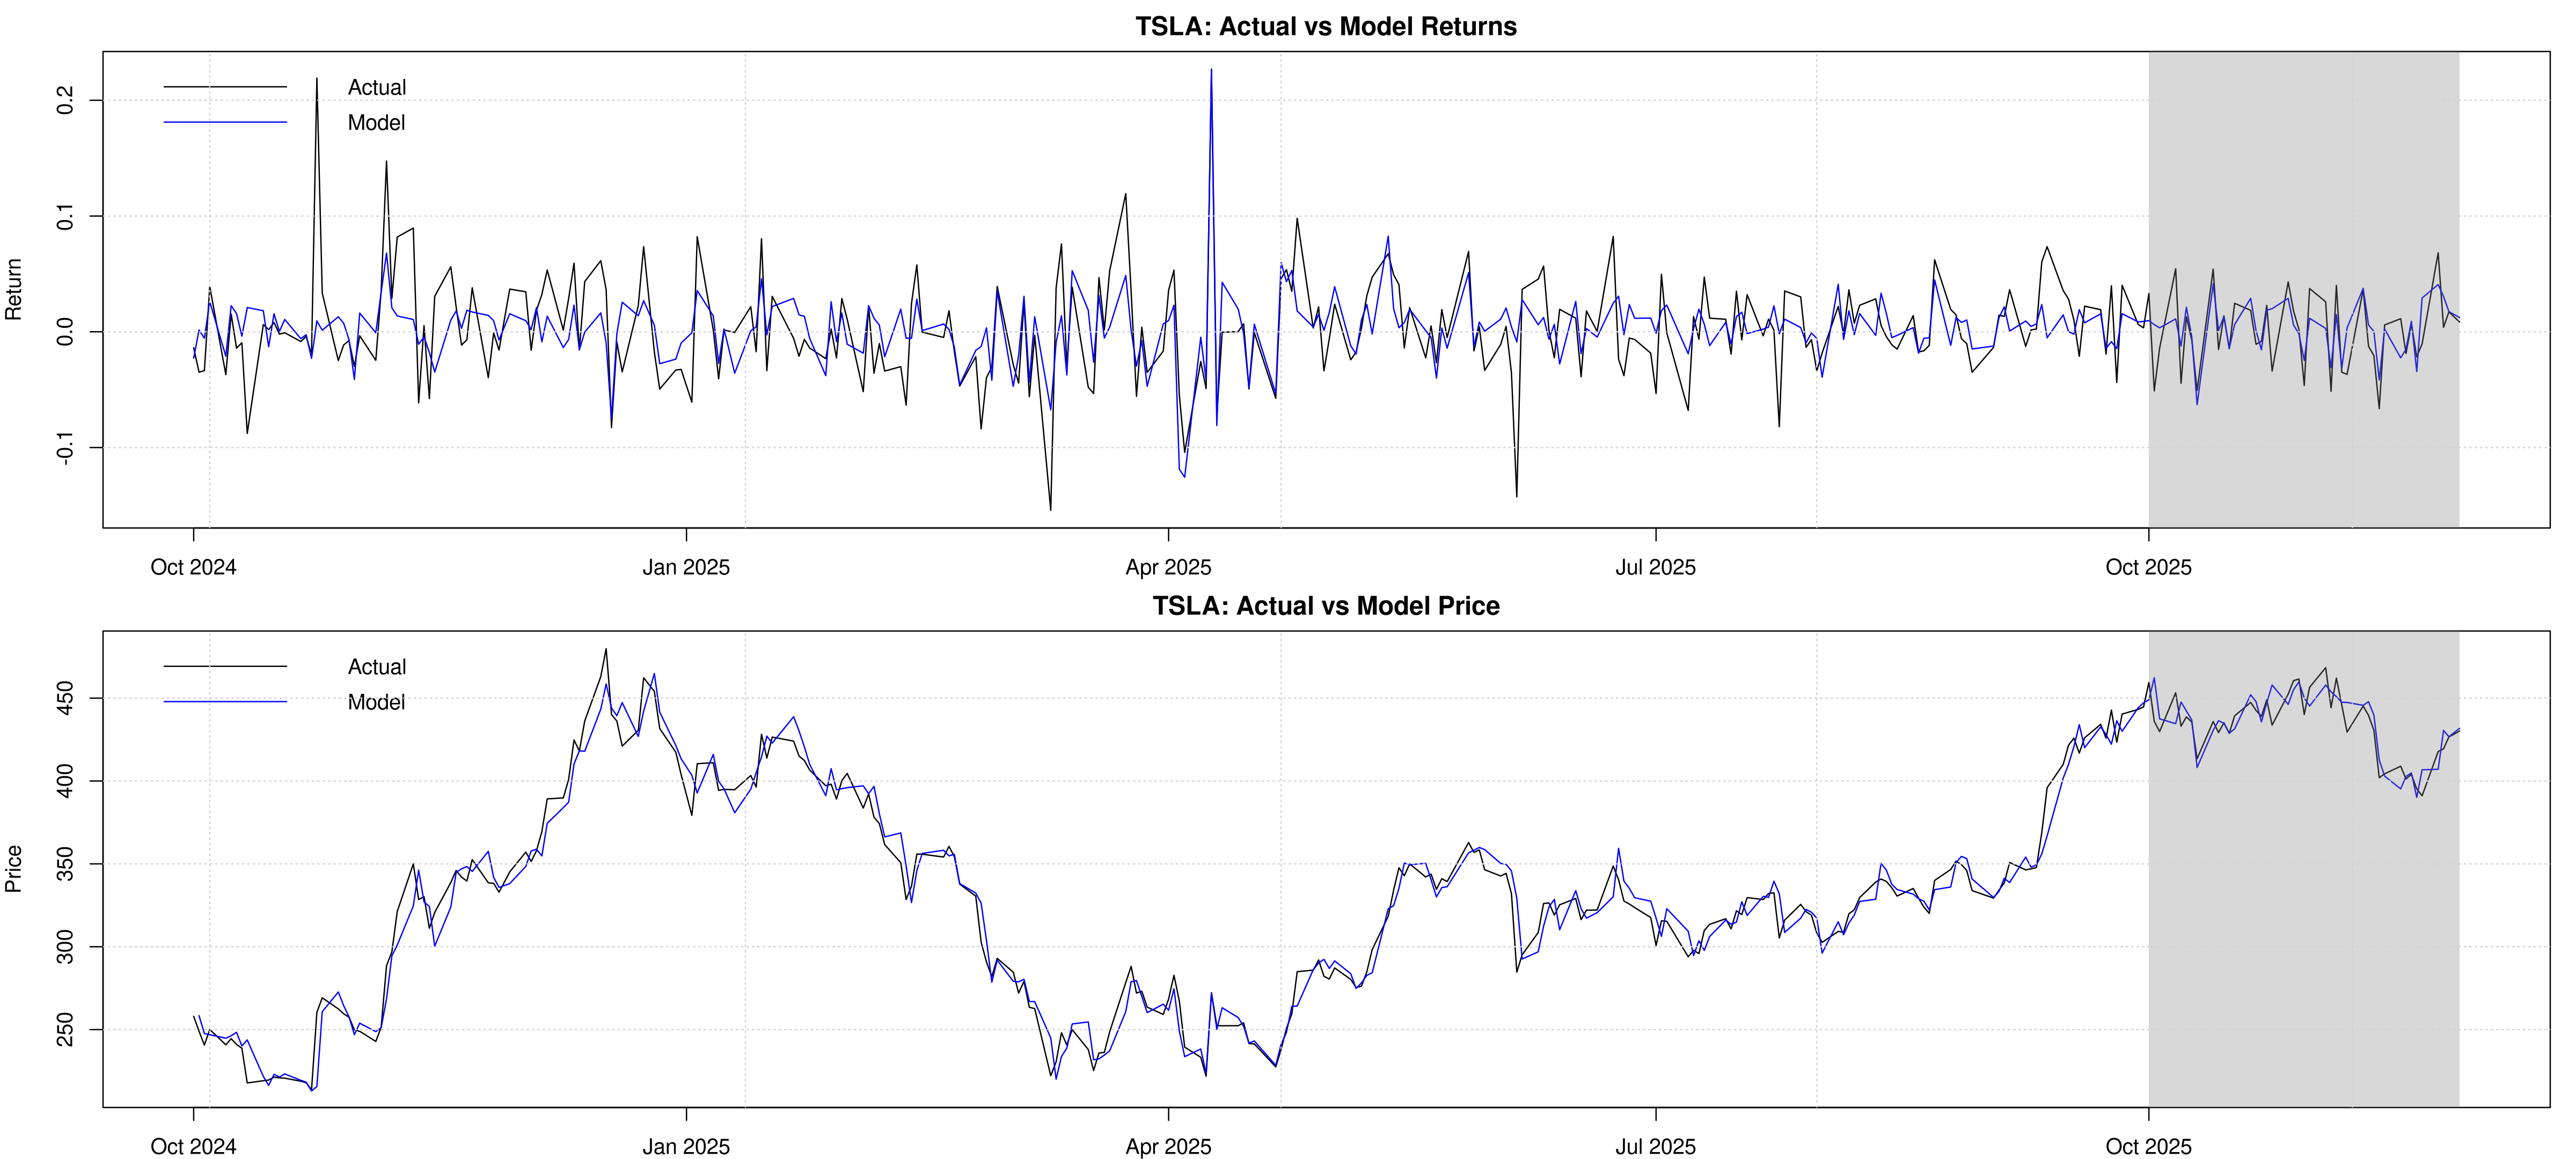

In [12]:
oos_start <- min(plot_df$date[plot_df$is_oos], na.rm=TRUE)
oos_end   <- max(plot_df$date[plot_df$is_oos], na.rm=TRUE)

par(mfrow=c(2,1), mar=c(2,4,2,1))

# Returns
plot(plot_df$date, plot_df$returns, type="l",
     main=sprintf("%s: Actual vs Model Returns", ticker), ylab="Return")
lines(plot_df$date, plot_df$model_ret, col="blue")
rect(oos_start, par("usr")[3], oos_end, par("usr")[4],
     col=rgb(0.5,0.5,0.5,0.3), border=NA)
legend("topleft", legend=c("Actual","Model"), col=c("black","blue"), lty=1, bty="n")
grid()

# Prices
plot(plot_df$date, plot_df$close, type="l",
     main=sprintf("%s: Actual vs Model Price", ticker), ylab="Price")
lines(plot_df$date, plot_df$model_price, col="blue")
rect(oos_start, par("usr")[3], oos_end, par("usr")[4],
     col=rgb(0.5,0.5,0.5,0.3), border=NA)
legend("topleft", legend=c("Actual","Model"), col=c("black","blue"), lty=1, bty="n")
grid()
par(mfrow=c(1,1))

### MSTR

In [13]:
ticker <- "MSTR"
asset  <- read.csv(sprintf("../../../data/%s.Daily.csv", ticker))
asset$index <- as.integer(gsub("-","", asset$timestamp))
rownames(asset) <- asset$index
asset$returns   <- c(NA, diff(asset$close)/head(asset$close,-1))

merged_data <- merge(fff, asset[,"returns",drop=FALSE], by="row.names", all=FALSE)
rownames(merged_data) <- as.integer(merged_data$Row.names)
merged_data$Row.names <- NULL

train <- na.omit(merged_data[rownames(merged_data) >= start_date &
                              rownames(merged_data) <= end_date, ])
test  <- merged_data[rownames(merged_data) > end_date, ]

ff_model <- lm(I(returns - RF) ~ Mkt.RF + SMB + HML, data=train)
oot_returns <- predict(ff_model, newdata=test)

params <- list(
    alpha    = coef(ff_model)["(Intercept)"],
    beta_mkt = coef(ff_model)["Mkt.RF"],
    beta_smb = coef(ff_model)["SMB"],
    beta_hml = coef(ff_model)["HML"]
)
generate_report(params, ticker)


Fama-French Three Factor Model Analysis for MSTR
Interpretation:
-     alpha: 0.0034. Positive. Outperforming the market.
- beta_mkt:  1.7984. Aggressive. High sensitivity to market swings.
- beta_smb:  1.7281. Positive. Asset behaves like Small Caps.
- beta_hml:  -0.6077. Negative. Asset behaves like Growth stocks.


## Coca-Cola

In [14]:
ticker <- "KO"
asset  <- read.csv(sprintf("../../../data/%s.Daily.csv", ticker))
asset$index <- as.integer(gsub("-","", asset$timestamp))
rownames(asset) <- asset$index
asset$returns   <- c(NA, diff(asset$close)/head(asset$close,-1))

merged_data <- merge(fff, asset[,"returns",drop=FALSE], by="row.names", all=FALSE)
rownames(merged_data) <- as.integer(merged_data$Row.names)
merged_data$Row.names <- NULL

train <- na.omit(merged_data[rownames(merged_data) >= start_date &
                              rownames(merged_data) <= end_date, ])
test  <- merged_data[rownames(merged_data) > end_date, ]

ff_model <- lm(I(returns - RF) ~ Mkt.RF + SMB + HML, data=train)
oot_returns <- predict(ff_model, newdata=test)

params <- list(
    alpha    = coef(ff_model)["(Intercept)"],
    beta_mkt = coef(ff_model)["Mkt.RF"],
    beta_smb = coef(ff_model)["SMB"],
    beta_hml = coef(ff_model)["HML"]
)
generate_report(params, ticker)


Fama-French Three Factor Model Analysis for KO
Interpretation:
-     alpha: -0.0007. Negative. Underperforming the market.
- beta_mkt:  0.2206. Defensive. Low sensitivity to market swings.
- beta_smb:  -0.4573. Negative. Asset behaves like Large Caps.
- beta_hml:  0.3253. Positive. Asset behaves like Value stocks.


## What can be done next to improve on this?
- Experiment with the idea what if Fama French factors were available daily as opposed to being published once a month
- This way the asset price can be more aware of the market condition
- Rolling regression